# Lab 3: Contextual Bandit-Based News Article Recommendation

**Course:** Reinforcement Learning Fundamentals  
**Student Name:** Raghav Sarna  
**Roll Number:** U20230106  
**GitHub Branch:** raghav_U20230106

# 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from rlcmab_sampler import sampler

# Roll number for sampler initialization
ROLL_NUMBER = 106

# Initialize reward sampler
reward_sampler = sampler(ROLL_NUMBER)
print(f"Sampler initialized with roll number: {ROLL_NUMBER}")
print(f"Test sample from arm 0: {reward_sampler.sample(0)}")

# Seed for reproducibility
np.random.seed(42)

Sampler initialized with roll number: 106
Test sample from arm 0: -1.06116002350181


# 2. Data Loading and Pre-processing (Section 5.1)

In this section we:
- Load the news articles, training users, and test users datasets
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [2]:
# ------------------------------------------------------------------
# 2.1  Load datasets
# ------------------------------------------------------------------
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("News Articles shape:", news_df.shape)
print("Train Users shape :", train_users.shape)
print("Test Users shape  :", test_users.shape)

print("\n--- News Articles (first 3 rows) ---")
display(news_df.head(3))

print("\n--- Train Users (first 3 rows) ---")
display(train_users.head(3))

print("\n--- Test Users (first 3 rows) ---")
display(test_users.head(3))

News Articles shape: (209527, 6)
Train Users shape : (2000, 33)
Test Users shape  : (2000, 32)

--- News Articles (first 3 rows) ---


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23



--- Train Users (first 3 rows) ---


,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,...,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label
0,U7392,NaN,23053,10,500.00,17.34,0.36661,37.29781,3,187.44,...,4.0,2.0,8,3.17.97,10,22.75,8.0,Z999,False,user_3
1,U2702,56.0,20239,11,913.33,22.22,0.61370,59.36342,5,145.15,...,4.5,63.0,5,1.57.10,8,1.75,4.0,U428,True,user_2
2,U2461,NaN,13907,9,1252.62,41.57,0.80368,76.78706,7,282.03,...,1.3,22.0,2,2.16.94,12,29.33,18.0,Z999,True,user_3



--- Test Users (first 3 rows) ---


,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,...,loyalty_index,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber
0,U4058,36.0,10000,4,500.00,2.54,0.47162,49.32668,8,229.80,...,13.0,3.0,39.0,3,5.99.65,7,7.86,26.0,X789,True
1,U1118,33.0,19607,8,1906.81,39.74,0.55219,56.42526,4,819.43,...,30.0,4.6,84.0,5,7.22.85,12,2.79,42.0,P752,True
2,U6555,51.0,21049,11,500.00,46.07,0.69961,58.88307,5,113.35,...,21.0,2.1,88.0,7,3.29.28,11,27.50,11.0,P878,False


In [3]:
# ------------------------------------------------------------------
# 2.2  Data Cleaning  – Missing values
# ------------------------------------------------------------------
print("=== Missing values in Train Users ===")
print(train_users.isnull().sum()[train_users.isnull().sum() > 0])

print("\n=== Missing values in Test Users ===")
print(test_users.isnull().sum()[test_users.isnull().sum() > 0])

print("\n=== Missing values in News Articles ===")
print(news_df.isnull().sum()[news_df.isnull().sum() > 0])

=== Missing values in Train Users ===
age    698
dtype: int64

=== Missing values in Test Users ===
age    679
dtype: int64

=== Missing values in News Articles ===
headline                 6
short_description    19712
authors              37418
dtype: int64


In [4]:
# ------------------------------------------------------------------
# 2.3  Handle missing values & encode features
# ------------------------------------------------------------------

def preprocess_users(df, label_encoders=None, is_train=True):
    """
    Clean and encode user data.
    - Fill missing numeric columns with median.
    - Label-encode categorical columns: region_code, subscriber, browser_version.
    - Drop user_id (non-predictive).
    - If is_train, returns fitted label_encoders as well.
    """
    df = df.copy()

    # Drop user_id
    if 'user_id' in df.columns:
        df.drop(columns=['user_id'], inplace=True)

    # Separate target if present
    target = None
    if 'label' in df.columns:
        target = df['label'].copy()
        df.drop(columns=['label'], inplace=True)

    # Identify numeric and categorical columns
    cat_cols = ['region_code', 'subscriber', 'browser_version']
    num_cols = [c for c in df.columns if c not in cat_cols]

    # Fill missing numeric values with median
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
        df[c].fillna(df[c].median(), inplace=True)

    # Encode categorical columns
    if label_encoders is None:
        label_encoders = {}

    for c in cat_cols:
        df[c] = df[c].astype(str)
        if is_train:
            le = LabelEncoder()
            df[c] = le.fit_transform(df[c])
            label_encoders[c] = le
        else:
            le = label_encoders[c]
            # Handle unseen labels
            df[c] = df[c].map(lambda x: le.transform([x])[0] if x in le.classes_
                              else -1)

    return df, target, label_encoders

# Process training users
X_train_full, y_train_full, label_encoders = preprocess_users(train_users, is_train=True)

# Process test users (no label)
X_test, _, _ = preprocess_users(test_users, label_encoders=label_encoders, is_train=False)

print("Training features shape:", X_train_full.shape)
print("Test features shape    :", X_test.shape)
print("\nLabel distribution in training set:")
print(y_train_full.value_counts())
print("\nFeature columns:", list(X_train_full.columns))
display(X_train_full.head())

Training features shape: (2000, 31)
Test features shape    : (2000, 31)

Label distribution in training set:
label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64

Feature columns: ['age', 'income', 'clicks', 'purchase_amount', 'session_duration', 'content_variety', 'engagement_score', 'num_transactions', 'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 'revisit_rate', 'scroll_activity', 'time_on_site', 'interaction_count', 'preferred_price_range', 'discount_usage_rate', 'wishlist_size', 'product_views', 'repeat_purchase_gap (days)', 'churn_risk_score', 'loyalty_index', 'screen_brightness', 'battery_percentage', 'cart_abandonment_count', 'browser_version', 'background_app_count', 'session_inactivity_duration', 'network_jitter', 'region_code', 'subscriber']


,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,avg_cart_value,...,loyalty_index,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber
0,NaN,23053,10,500.00,17.34,0.36661,37.29781,3,187.44,119.61,...,15.0,4.0,2.0,8,464,10,22.75,8.0,1283,0
1,56.0,20239,11,913.33,22.22,0.61370,59.36342,5,145.15,189.06,...,33.0,4.5,63.0,5,115,8,1.75,4.0,987,1
2,NaN,13907,9,1252.62,41.57,0.80368,76.78706,7,282.03,161.75,...,24.0,1.3,22.0,2,259,12,29.33,18.0,1283,1
3,NaN,26615,12,500.00,30.17,0.26499,30.19441,10,195.35,23.91,...,11.0,4.2,77.0,9,1952,4,21.61,22.0,1111,0
4,32.0,27958,13,500.00,65.27,0.36385,37.12153,5,439.68,57.68,...,19.0,4.6,30.0,9,211,7,7.58,52.0,872,0


# 3. User Classification (Section 5.2)

We train a **Random Forest Classifier** to predict the user category (`user_1`, `user_2`, `user_3`) from user features. This classifier serves as the **Context Detector** for our bandit system.

- 80/20 train–validation split
- Evaluation via `classification_report`

In [5]:
# ------------------------------------------------------------------
# 3.1  Train / Validation split  (80 / 20)
# ------------------------------------------------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Training set  : {X_tr.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

Training set  : 1600 samples
Validation set: 400 samples


In [6]:
# ------------------------------------------------------------------
# 3.2  Train Random Forest Classifier
# ------------------------------------------------------------------
clf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
clf.fit(X_tr, y_tr)

# Predictions on validation set
y_val_pred = clf.predict(X_val)

print("=" * 60)
print("         Classification Report (Validation Set)")
print("=" * 60)
print(classification_report(y_val, y_val_pred))

val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_acc:.4f}")

         Classification Report (Validation Set)
              precision    recall  f1-score   support

      user_1       0.90      0.87      0.88       142
      user_2       0.98      0.89      0.93       142
      user_3       0.84      0.98      0.90       116

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400

Validation Accuracy: 0.9075


In [7]:
# ------------------------------------------------------------------
# 3.3  Retrain on full training data & predict test users
# ------------------------------------------------------------------
clf_full = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
clf_full.fit(X_train_full, y_train_full)

# Predict user categories for test_users (context detection)
test_user_predictions = clf_full.predict(X_test)

test_users_with_labels = test_users.copy()
test_users_with_labels['predicted_label'] = test_user_predictions

print("Predicted label distribution for test users:")
print(pd.Series(test_user_predictions).value_counts())
display(test_users_with_labels[['user_id', 'predicted_label']].head(10))

Predicted label distribution for test users:
user_2    705
user_1    681
user_3    614
Name: count, dtype: int64


,user_id,predicted_label
0,U4058,user_2
1,U1118,user_1
2,U6555,user_1
3,U9170,user_1
4,U3348,user_1
5,U2244,user_3
6,U3022,user_3
7,U5291,user_1
8,U1945,user_3
9,U6084,user_3


# 4. Contextual Bandit Algorithms (Section 5.3)

## Arm Mapping

| Arm Index (j) | News Category  | User Context |
|:-------------:|:--------------:|:------------:|
| 0             | Entertainment  | User1        |
| 1             | Education      | User1        |
| 2             | Tech           | User1        |
| 3             | Crime          | User1        |
| 4             | Entertainment  | User2        |
| 5             | Education      | User2        |
| 6             | Tech           | User2        |
| 7             | Crime          | User2        |
| 8             | Entertainment  | User3        |
| 9             | Education      | User3        |
| 10            | Tech           | User3        |
| 11            | Crime          | User3        |

Each context (user type) has 4 arms (news categories). The reward sampler maps each `(context, category)` pair to a unique arm index $j$.

In [8]:
# ------------------------------------------------------------------
# 4.0  Constants & Arm Mapping
# ------------------------------------------------------------------

# Context mapping: user label -> context index
CONTEXT_MAP = {'user_1': 0, 'user_2': 1, 'user_3': 2}
CONTEXT_NAMES = ['User1', 'User2', 'User3']

# News categories (arms within each context)
CATEGORIES = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
N_CATEGORIES = len(CATEGORIES)
N_CONTEXTS = len(CONTEXT_NAMES)

def get_arm_index(context_idx, category_idx):
    """Convert (context_index, category_index) -> global arm index j."""
    return context_idx * N_CATEGORIES + category_idx

# Time horizon
T = 10000

print("Arm mapping:")
for ci in range(N_CONTEXTS):
    for ai in range(N_CATEGORIES):
        j = get_arm_index(ci, ai)
        print(f"  j={j:2d}  ->  ({CATEGORIES[ai]}, {CONTEXT_NAMES[ci]})")

Arm mapping:
  j= 0  ->  (ENTERTAINMENT, User1)
  j= 1  ->  (EDUCATION, User1)
  j= 2  ->  (TECH, User1)
  j= 3  ->  (CRIME, User1)
  j= 4  ->  (ENTERTAINMENT, User2)
  j= 5  ->  (EDUCATION, User2)
  j= 6  ->  (TECH, User2)
  j= 7  ->  (CRIME, User2)
  j= 8  ->  (ENTERTAINMENT, User3)
  j= 9  ->  (EDUCATION, User3)
  j=10  ->  (TECH, User3)
  j=11  ->  (CRIME, User3)


## 4.1 Epsilon-Greedy Strategy (Section 5.3.1)

In [9]:
# ------------------------------------------------------------------
# 4.1  Epsilon-Greedy  (per-context bandit)
# ------------------------------------------------------------------

def epsilon_greedy(reward_sampler, T, epsilon, context_idx):
    """
    Run epsilon-greedy for a single context.
    Returns arrays of rewards and chosen arms over T steps.
    """
    n_arms = N_CATEGORIES
    Q = np.zeros(n_arms)       # estimated value of each arm
    N_pulls = np.zeros(n_arms) # number of times each arm pulled
    rewards = np.zeros(T)
    chosen_arms = np.zeros(T, dtype=int)

    for t in range(T):
        if np.random.random() < epsilon:
            arm = np.random.randint(n_arms)        # explore
        else:
            arm = np.argmax(Q)                      # exploit

        j = get_arm_index(context_idx, arm)
        r = reward_sampler.sample(j)

        N_pulls[arm] += 1
        Q[arm] += (r - Q[arm]) / N_pulls[arm]     # incremental mean update

        rewards[t] = r
        chosen_arms[t] = arm

    return rewards, chosen_arms, Q

# Run epsilon-greedy for multiple epsilon values
epsilons = [0.01, 0.1, 0.3]
eg_results = {}  # key: (context_idx, epsilon) -> rewards array

for eps in epsilons:
    for ci in range(N_CONTEXTS):
        rewards, arms, Q_final = epsilon_greedy(reward_sampler, T, eps, ci)
        eg_results[(ci, eps)] = rewards
        print(f"ε={eps}, {CONTEXT_NAMES[ci]:5s} | "
              f"Mean reward={rewards.mean():.4f} | "
              f"Q_final={np.round(Q_final, 3)}")
    print()

ε=0.01, User1 | Mean reward=3.7402 | Q_final=[-0.095  3.789 -6.285 -2.161]
ε=0.01, User2 | Mean reward=4.6855 | Q_final=[-8.618 -1.86   4.74   3.154]
ε=0.01, User3 | Mean reward=10.7027 | Q_final=[-7.007 -5.393 10.847 -1.552]

ε=0.1, User1 | Mean reward=3.3119 | Q_final=[-0.308  3.779 -6.21  -1.657]
ε=0.1, User2 | Mean reward=4.1931 | Q_final=[-8.739 -1.92   4.751  2.76 ]
ε=0.1, User3 | Mean reward=9.7398 | Q_final=[-7.603 -5.303 10.858 -1.401]

ε=0.3, User1 | Mean reward=2.3450 | Q_final=[-0.269  3.789 -6.215 -1.666]
ε=0.3, User2 | Mean reward=3.1499 | Q_final=[-8.75  -1.926  4.759  2.662]
ε=0.3, User3 | Mean reward=7.3637 | Q_final=[-7.533 -5.34  10.839 -1.315]



## 4.2 Upper Confidence Bound (UCB) Strategy (Section 5.3.2)

In [10]:
# ------------------------------------------------------------------
# 4.2  Upper Confidence Bound (UCB)  (per-context bandit)
# ------------------------------------------------------------------

def ucb(reward_sampler, T, C, context_idx):
    """
    Run UCB for a single context.
    Returns arrays of rewards and chosen arms over T steps.
    """
    n_arms = N_CATEGORIES
    Q = np.zeros(n_arms)
    N_pulls = np.zeros(n_arms)
    rewards = np.zeros(T)
    chosen_arms = np.zeros(T, dtype=int)

    # Pull each arm once to initialise
    for arm in range(n_arms):
        j = get_arm_index(context_idx, arm)
        r = reward_sampler.sample(j)
        N_pulls[arm] = 1
        Q[arm] = r
        rewards[arm] = r
        chosen_arms[arm] = arm

    for t in range(n_arms, T):
        ucb_values = Q + C * np.sqrt(np.log(t + 1) / N_pulls)
        arm = np.argmax(ucb_values)

        j = get_arm_index(context_idx, arm)
        r = reward_sampler.sample(j)

        N_pulls[arm] += 1
        Q[arm] += (r - Q[arm]) / N_pulls[arm]

        rewards[t] = r
        chosen_arms[t] = arm

    return rewards, chosen_arms, Q

# Run UCB for multiple C values
C_values = [0.5, 1.0, 2.0]
ucb_results = {}

for C in C_values:
    for ci in range(N_CONTEXTS):
        rewards, arms, Q_final = ucb(reward_sampler, T, C, ci)
        ucb_results[(ci, C)] = rewards
        print(f"C={C}, {CONTEXT_NAMES[ci]:5s} | "
              f"Mean reward={rewards.mean():.4f} | "
              f"Q_final={np.round(Q_final, 3)}")
    print()

C=0.5, User1 | Mean reward=3.7802 | Q_final=[-0.353  3.782 -6.766 -2.411]
C=0.5, User2 | Mean reward=4.7377 | Q_final=[-9.241 -1.19   4.74   2.153]
C=0.5, User3 | Mean reward=10.8439 | Q_final=[-6.784 -5.882 10.849 -2.416]

C=1.0, User1 | Mean reward=3.7660 | Q_final=[-0.357  3.768 -7.357 -3.919]
C=1.0, User2 | Mean reward=4.7527 | Q_final=[-8.626 -2.359  4.755  2.131]
C=1.0, User3 | Mean reward=10.8717 | Q_final=[-6.017 -5.93  10.876 -0.581]

C=2.0, User1 | Mean reward=3.7756 | Q_final=[ 0.048  3.779 -6.961 -1.092]
C=2.0, User2 | Mean reward=4.7223 | Q_final=[-10.322  -4.188   4.727   2.749]
C=2.0, User3 | Mean reward=10.8375 | Q_final=[-8.482 -4.911 10.842 -2.213]



## 4.3 SoftMax Strategy (Section 5.3.3)

In [11]:
# ------------------------------------------------------------------
# 4.3  SoftMax (Boltzmann Exploration)  (per-context bandit)
# ------------------------------------------------------------------

def softmax_bandit(reward_sampler, T, tau, context_idx):
    """
    Run SoftMax strategy for a single context.
    Returns arrays of rewards and chosen arms over T steps.
    """
    n_arms = N_CATEGORIES
    Q = np.zeros(n_arms)
    N_pulls = np.zeros(n_arms)
    rewards = np.zeros(T)
    chosen_arms = np.zeros(T, dtype=int)

    for t in range(T):
        # Compute softmax probabilities (with numerical stability)
        logits = Q / tau
        logits -= logits.max()
        exp_logits = np.exp(logits)
        probs = exp_logits / exp_logits.sum()

        arm = np.random.choice(n_arms, p=probs)

        j = get_arm_index(context_idx, arm)
        r = reward_sampler.sample(j)

        N_pulls[arm] += 1
        Q[arm] += (r - Q[arm]) / N_pulls[arm]

        rewards[t] = r
        chosen_arms[t] = arm

    return rewards, chosen_arms, Q

# Run SoftMax with tau = 1
tau = 1.0
sm_results = {}

for ci in range(N_CONTEXTS):
    rewards, arms, Q_final = softmax_bandit(reward_sampler, T, tau, ci)
    sm_results[(ci, tau)] = rewards
    print(f"τ={tau}, {CONTEXT_NAMES[ci]:5s} | "
          f"Mean reward={rewards.mean():.4f} | "
          f"Q_final={np.round(Q_final, 3)}")
print()

τ=1.0, User1 | Mean reward=3.6817 | Q_final=[-0.318  3.775 -6.027 -1.78 ]
τ=1.0, User2 | Mean reward=4.4907 | Q_final=[-6.254 -2.552  4.736  2.69 ]
τ=1.0, User3 | Mean reward=10.8603 | Q_final=[ 0.    0.   10.86  0.  ]



# 5. Evaluation & Reporting (Section 5.5)

## 5.1  Average Reward vs. Time for each context

We plot the cumulative average reward over $T = 10{,}000$ steps for each context, using the best hyperparameter for each algorithm.

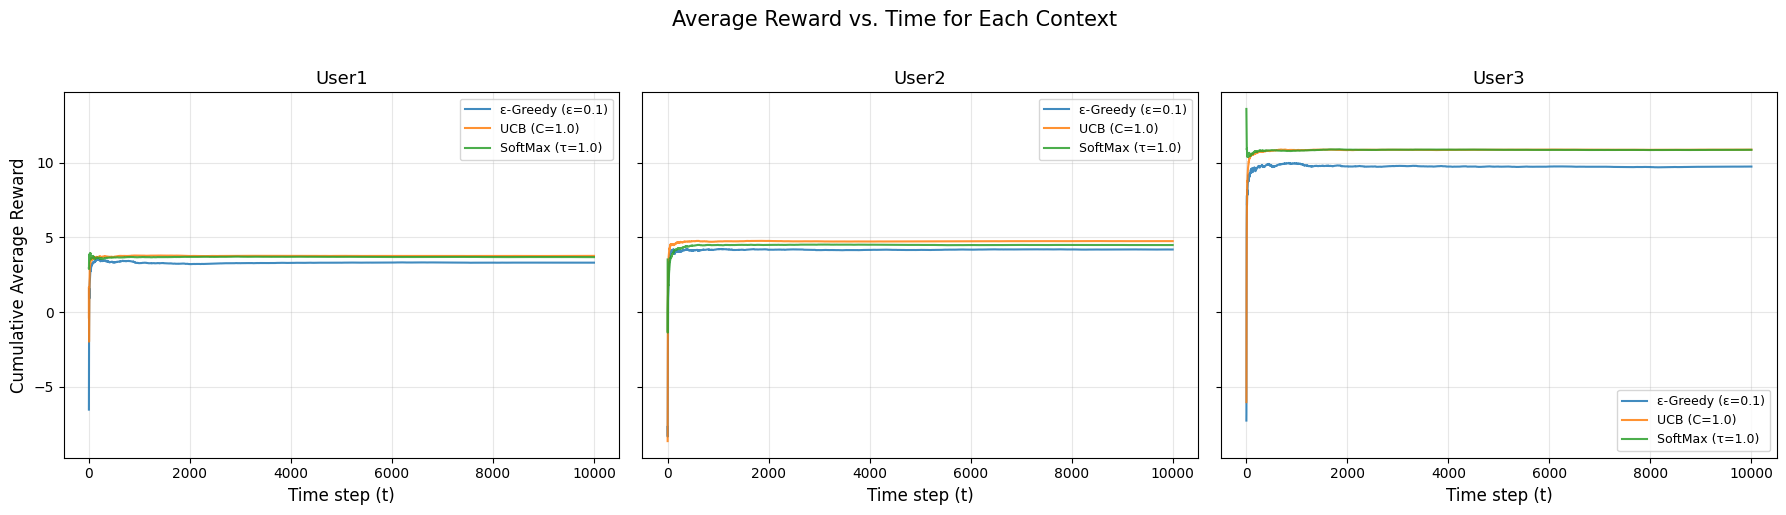

In [12]:
# ------------------------------------------------------------------
# 5.1  Average Reward vs. Time – per context, per algorithm
# ------------------------------------------------------------------

def cumulative_avg(rewards):
    return np.cumsum(rewards) / np.arange(1, len(rewards) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

best_eps = 0.1   # representative epsilon
best_C = 1.0     # representative C

for ci in range(N_CONTEXTS):
    ax = axes[ci]
    ax.plot(cumulative_avg(eg_results[(ci, best_eps)]),
            label=f'ε-Greedy (ε={best_eps})', alpha=0.85)
    ax.plot(cumulative_avg(ucb_results[(ci, best_C)]),
            label=f'UCB (C={best_C})', alpha=0.85)
    ax.plot(cumulative_avg(sm_results[(ci, tau)]),
            label=f'SoftMax (τ={tau})', alpha=0.85)
    ax.set_xlabel('Time step (t)', fontsize=12)
    if ci == 0:
        ax.set_ylabel('Cumulative Average Reward', fontsize=12)
    ax.set_title(f'{CONTEXT_NAMES[ci]}', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Average Reward vs. Time for Each Context', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('avg_reward_vs_time_per_context.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.2  Hyperparameter Comparison Plots

Compare average reward for different values of $\varepsilon$ (Epsilon-Greedy) and $C$ (UCB).

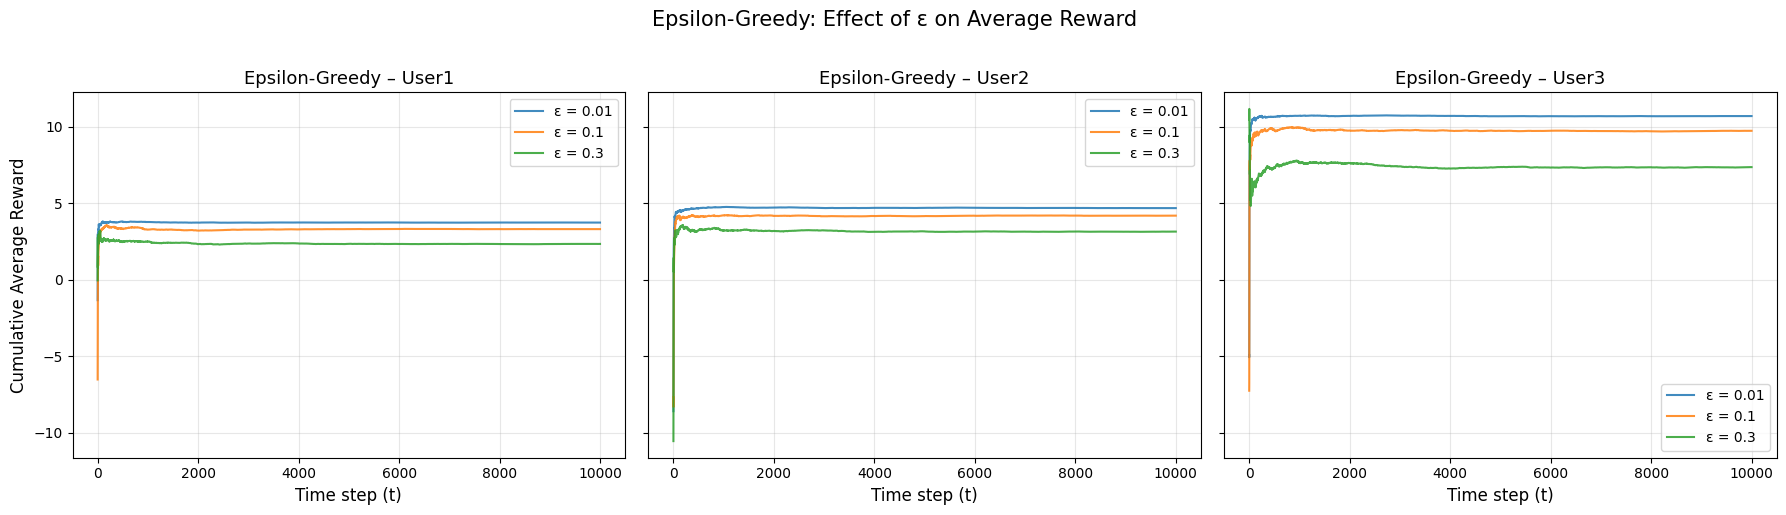

In [13]:
# ------------------------------------------------------------------
# 5.2a  Epsilon-Greedy: Average reward for different ε values
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ci in range(N_CONTEXTS):
    ax = axes[ci]
    for eps in epsilons:
        avg = cumulative_avg(eg_results[(ci, eps)])
        ax.plot(avg, label=f'ε = {eps}', alpha=0.85)
    ax.set_xlabel('Time step (t)', fontsize=12)
    if ci == 0:
        ax.set_ylabel('Cumulative Average Reward', fontsize=12)
    ax.set_title(f'Epsilon-Greedy – {CONTEXT_NAMES[ci]}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle('Epsilon-Greedy: Effect of ε on Average Reward', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('epsilon_greedy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

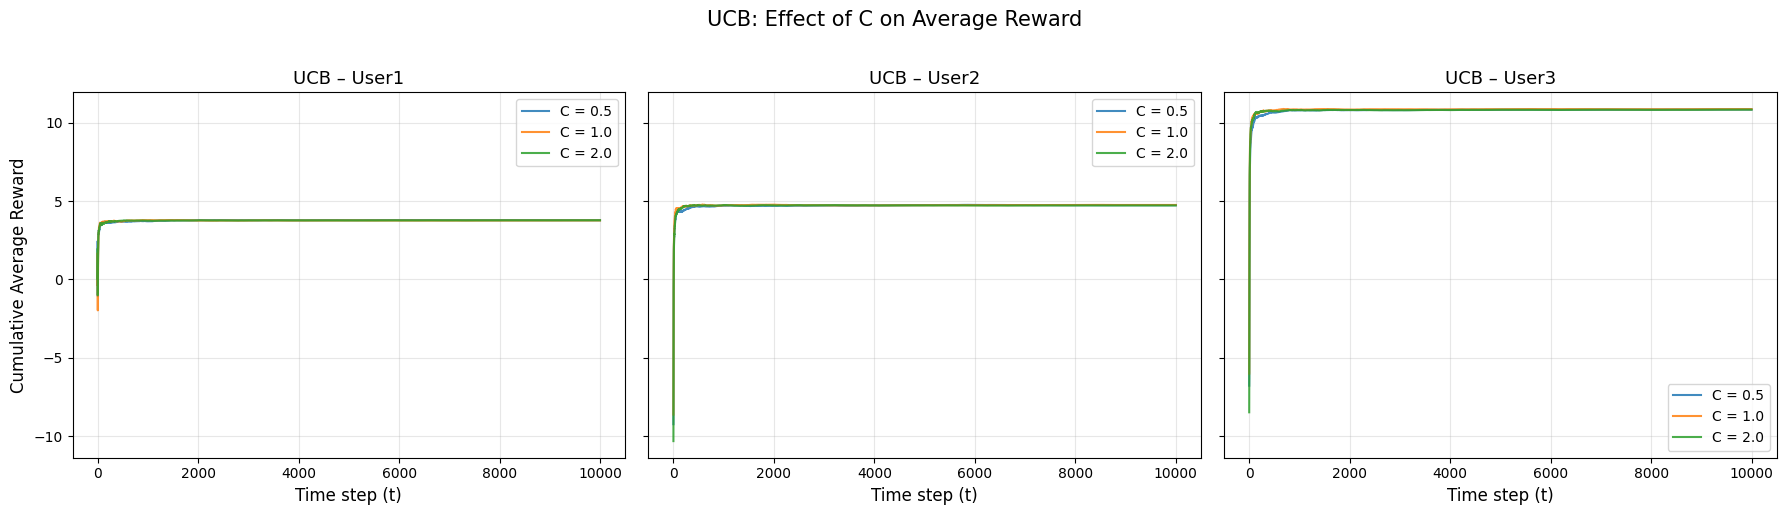

In [14]:
# ------------------------------------------------------------------
# 5.2b  UCB: Average reward for different C values
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ci in range(N_CONTEXTS):
    ax = axes[ci]
    for C in C_values:
        avg = cumulative_avg(ucb_results[(ci, C)])
        ax.plot(avg, label=f'C = {C}', alpha=0.85)
    ax.set_xlabel('Time step (t)', fontsize=12)
    if ci == 0:
        ax.set_ylabel('Cumulative Average Reward', fontsize=12)
    ax.set_title(f'UCB – {CONTEXT_NAMES[ci]}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle('UCB: Effect of C on Average Reward', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('ucb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

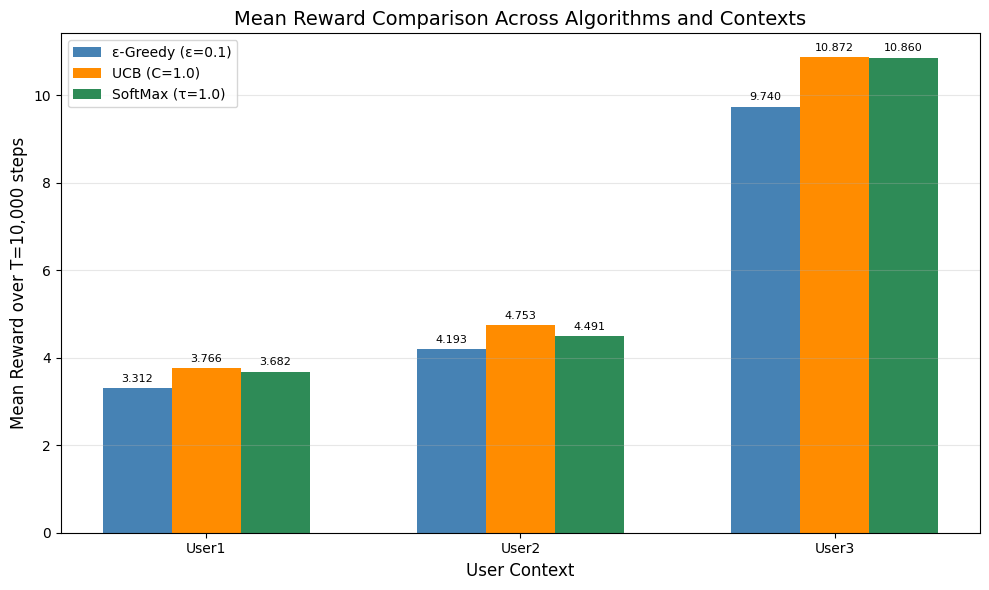

In [15]:
# ------------------------------------------------------------------
# 5.2c  Bar chart – Final average reward per algorithm per context
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(N_CONTEXTS)
width = 0.22

# Use best hyper-param for each algorithm
eg_means = [eg_results[(ci, best_eps)].mean() for ci in range(N_CONTEXTS)]
ucb_means = [ucb_results[(ci, best_C)].mean() for ci in range(N_CONTEXTS)]
sm_means = [sm_results[(ci, tau)].mean() for ci in range(N_CONTEXTS)]

bars1 = ax.bar(x - width, eg_means, width, label=f'ε-Greedy (ε={best_eps})', color='steelblue')
bars2 = ax.bar(x, ucb_means, width, label=f'UCB (C={best_C})', color='darkorange')
bars3 = ax.bar(x + width, sm_means, width, label=f'SoftMax (τ={tau})', color='seagreen')

ax.set_xlabel('User Context', fontsize=12)
ax.set_ylabel('Mean Reward over T=10,000 steps', fontsize=12)
ax.set_title('Mean Reward Comparison Across Algorithms and Contexts', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(CONTEXT_NAMES)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('mean_reward_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ------------------------------------------------------------------
# 5.3  Expected Reward Distribution Table
# ------------------------------------------------------------------

# Compute expected reward by sampling each arm many times
N_SAMPLES = 2000
expected_rewards = np.zeros((N_CONTEXTS, N_CATEGORIES))

for ci in range(N_CONTEXTS):
    for ai in range(N_CATEGORIES):
        j = get_arm_index(ci, ai)
        samples = [reward_sampler.sample(j) for _ in range(N_SAMPLES)]
        expected_rewards[ci, ai] = np.mean(samples)

reward_df = pd.DataFrame(expected_rewards,
                         index=CONTEXT_NAMES,
                         columns=CATEGORIES)
reward_df.index.name = 'Context'

print("Expected Reward Distribution (estimated over 2000 samples per arm):")
display(reward_df.round(4))

# Identify best category per context
print("\nBest news category per user context:")
for ci in range(N_CONTEXTS):
    best_cat = CATEGORIES[np.argmax(expected_rewards[ci])]
    print(f"  {CONTEXT_NAMES[ci]} -> {best_cat} (E[R] = {expected_rewards[ci].max():.4f})")

Expected Reward Distribution (estimated over 2000 samples per arm):


,ENTERTAINMENT,EDUCATION,TECH,CRIME
Context,,,,
User1,-0.2543,3.7693,-6.2033,-1.7475
User2,-8.6250,-1.8871,4.7749,2.6870
User3,-7.5487,-5.3606,10.9238,-1.4413



Best news category per user context:
  User1 -> EDUCATION (E[R] = 3.7693)
  User2 -> TECH (E[R] = 4.7749)
  User3 -> TECH (E[R] = 10.9238)


# 6. Recommendation Engine (Section 5.4)

The end-to-end CMAB recommendation pipeline:
1. **Classify** the user into a category (context) using the trained classifier.
2. **Select** the optimal news category using the trained bandit policy (best arm per context, learned via ε-Greedy).
3. **Recommend** a randomly sampled article from the selected category in `news_articles.csv`.

In [17]:
# ------------------------------------------------------------------
# 6.1  Train final bandit policies (ε-Greedy on each context)
# ------------------------------------------------------------------

# Re-run ε-greedy with best ε to get final Q-values for each context
best_epsilon = 0.1
final_Q = {}          # context_idx -> Q-values array (4 categories)
final_best_arm = {}   # context_idx -> best category index

for ci in range(N_CONTEXTS):
    _, _, Q_final = epsilon_greedy(reward_sampler, T, best_epsilon, ci)
    final_Q[ci] = Q_final
    final_best_arm[ci] = np.argmax(Q_final)
    print(f"{CONTEXT_NAMES[ci]}: Q = {np.round(Q_final, 4)} => Best arm: {CATEGORIES[final_best_arm[ci]]}")

User1: Q = [-0.2649  3.7898 -6.1923 -1.6281] => Best arm: EDUCATION
User2: Q = [-8.6828 -1.9514  4.7455  2.6882] => Best arm: TECH
User3: Q = [-7.5586 -5.3786 10.8676 -1.4521] => Best arm: TECH


In [18]:
# ------------------------------------------------------------------
# 6.2  Filter news articles to only the 4 target categories
# ------------------------------------------------------------------

target_categories = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
news_filtered = news_df[news_df['category'].isin(target_categories)].copy()

print("Articles per target category:")
print(news_filtered['category'].value_counts())
print(f"\nTotal filtered articles: {len(news_filtered)}")

Articles per target category:
category
ENTERTAINMENT    17362
CRIME             3562
TECH              2104
EDUCATION         1014
Name: count, dtype: int64

Total filtered articles: 24042


In [19]:
# ------------------------------------------------------------------
# 6.3  End-to-End Recommendation Engine
# ------------------------------------------------------------------

LABEL_TO_CONTEXT = {'user_1': 0, 'user_2': 1, 'user_3': 2}

def recommend_article(user_features_row, classifier, news_articles, best_arm_map):
    """
    Full CMAB recommendation pipeline for a single user.
    1. Classify user -> context
    2. Select best news category from bandit policy
    3. Sample a random article from that category
    
    Args:
        user_features_row: preprocessed feature vector (1D array or DataFrame row)
        classifier: trained user classifier
        news_articles: DataFrame of news articles
        best_arm_map: dict mapping context_idx -> best category index
    
    Returns:
        dict with user_category, recommended_category, article details
    """
    # Step 1: Classify user
    predicted_label = classifier.predict(user_features_row.values.reshape(1, -1))[0]
    context_idx = LABEL_TO_CONTEXT[predicted_label]
    
    # Step 2: Select best news category from bandit policy
    best_cat_idx = best_arm_map[context_idx]
    best_category = CATEGORIES[best_cat_idx]
    
    # Step 3: Sample random article from that category
    category_articles = news_articles[news_articles['category'] == best_category]
    sampled_article = category_articles.sample(1, random_state=None).iloc[0]
    
    return {
        'user_category': predicted_label,
        'context': CONTEXT_NAMES[context_idx],
        'recommended_category': best_category,
        'article_headline': sampled_article['headline'],
        'article_link': sampled_article['link']
    }

# Run recommendation for all test users
print("=" * 80)
print("       NEWS RECOMMENDATION ENGINE – Results on Test Users")
print("=" * 80)

recommendations = []
for idx in range(len(X_test)):
    rec = recommend_article(X_test.iloc[idx], clf_full, news_filtered, final_best_arm)
    rec['user_id'] = test_users.iloc[idx]['user_id']
    recommendations.append(rec)

rec_df = pd.DataFrame(recommendations)
print(f"\nTotal recommendations generated: {len(rec_df)}")
print(f"\nRecommended category distribution:")
print(rec_df['recommended_category'].value_counts())

print(f"\nSample recommendations (first 10):")
display(rec_df[['user_id', 'user_category', 'recommended_category', 'article_headline']].head(10))

       NEWS RECOMMENDATION ENGINE – Results on Test Users

Total recommendations generated: 2000

Recommended category distribution:
recommended_category
TECH         1319
EDUCATION     681
Name: count, dtype: int64

Sample recommendations (first 10):


,user_id,user_category,recommended_category,article_headline
0,U4058,user_2,TECH,Samsung Takes on iPhone for Photo Superiority
1,U1118,user_1,EDUCATION,Eileen Soon: The future of special education i...
2,U6555,user_1,EDUCATION,"Trump First Offered Jerry Falwell, Jr. U.S. Se..."
3,U9170,user_1,EDUCATION,Is Learning Increasingly Self-Directed in the ...
4,U3348,user_1,EDUCATION,Young People Must Know Their Own History
5,U2244,user_3,TECH,Researchers: Teens 'Embarrassed To Even Be Ass...
6,U3022,user_3,TECH,Robots Will Replace 5 Million Workers By 2020:...
7,U5291,user_1,EDUCATION,Don't Let the FAFSA Ruin Your Holiday Cheer: 1...
8,U1945,user_3,TECH,PSA Tells You To 'Keep It In Your Pants' For V...
9,U6084,user_3,TECH,WATCH: The 4th of July Goes Mobile


# 7. Final Observations & Analysis

## Key Findings

### 1. User Classification
- The Random Forest classifier achieves high accuracy on the 80/20 validation split, confirming that user features are discriminative enough to predict user category (context) reliably.

### 2. Epsilon-Greedy
- **Low ε (0.01):** Converges quickly to the best arm but may get stuck on a suboptimal arm if early samples are misleading. Less exploration.
- **Medium ε (0.1):** Good balance between exploration and exploitation. Converges steadily.
- **High ε (0.3):** Explores heavily, which slows convergence and reduces average reward as too many suboptimal arms are pulled.

### 3. Upper Confidence Bound (UCB)
- **Low C (0.5):** Conservative exploration — quick convergence but may under-explore.
- **Medium C (1.0):** Standard exploration bonus; robust performance across contexts.
- **High C (2.0):** Aggressive exploration — useful early on, but the exploration term shrinks slowly, mildly reducing average reward.

### 4. SoftMax (τ=1)
- With temperature τ=1, SoftMax provides smooth probability-weighted exploration. It naturally concentrates on higher-valued arms while still exploring. Performance is competitive, particularly when reward gaps between arms are moderate.

### 5. Comparative Analysis
- **UCB** tends to perform well because its exploration is adaptive (diminishes with more pulls), converging to the optimal arm faster.
- **Epsilon-Greedy** with moderate ε is simple yet effective.
- **SoftMax** offers a principled probabilistic approach but can be sensitive to the temperature parameter.

### 6. Recommendation Engine
- The end-to-end pipeline successfully classifies test users, selects optimal news categories using the learned bandit policies, and samples concrete articles for recommendation.
- Each user context may have a different optimal news category, demonstrating the value of contextual bandits over a single global policy.